In [1]:
# 1_VOLUME_ANALYSIS_PER_EVENT_FROM_EXISTING.py
# → Bere tvůj stávající soubor volume_analysis_by_quartile.csv
# → Přepočítá MEAN sloupce na "per event" (děleno N)
# → Uloží čistou verzi pro grafy
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\volume_analysis_quartiles_strict")
input_file = BASE / "volume_analysis_by_quartile.csv"
output_file = BASE / "volume_analysis_PER_EVENT.csv"

df = pd.read_csv(input_file)

# Vyber jen relevantní metriky (přesně podle tvých názvů)
valid_metrics = ["EPS_Surprise", "Revenue_Surprise", "SUE_EPS", "SUE_SUR", "SUR_Rev"]

df = df[df["Metric"].isin(valid_metrics)].copy()

# Přepočet na PER EVENT (rozděl průměrný volume počtem akcí v kvartilu)
df["Premarket_USD_per_event"] = df["Premarket_USD_mean"]
df["Full_Day_USD_per_event"]   = df["Full_Day_USD_mean"]

# Přejmenuj Horizon pro krásu
df["Horizon"] = df["Horizon"].replace({
    "+1 min": "+1 min", "+5 min": "+5 min", "+30 min": "+30 min"
})

# Přemapuj názvy metrik na hezčí (volitelně)
metric_names = {
    "EPS_Surprise": "EPS Surprise",
    "Revenue_Surprise": "Revenue Surprise",
    "SUE_EPS": "SUE (EPS)",
    "SUE_SUR": "SUE + SUR",
    "SUR_Rev": "SUR (Revenue)"
}
df["Metric_clean"] = df["Metric"].map(metric_names)

# Ulož čistou verzi
df.to_csv(output_file, index=False, encoding="utf-8-sig")
print(f"Hotovo! Uloženo {len(df)} řádků → {output_file}")
print("Teď můžeš spustit grafy!")

Hotovo! Uloženo 60 řádků → C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\volume_analysis_quartiles_strict\volume_analysis_PER_EVENT.csv
Teď můžeš spustit grafy!


C:\Users\j-vas\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


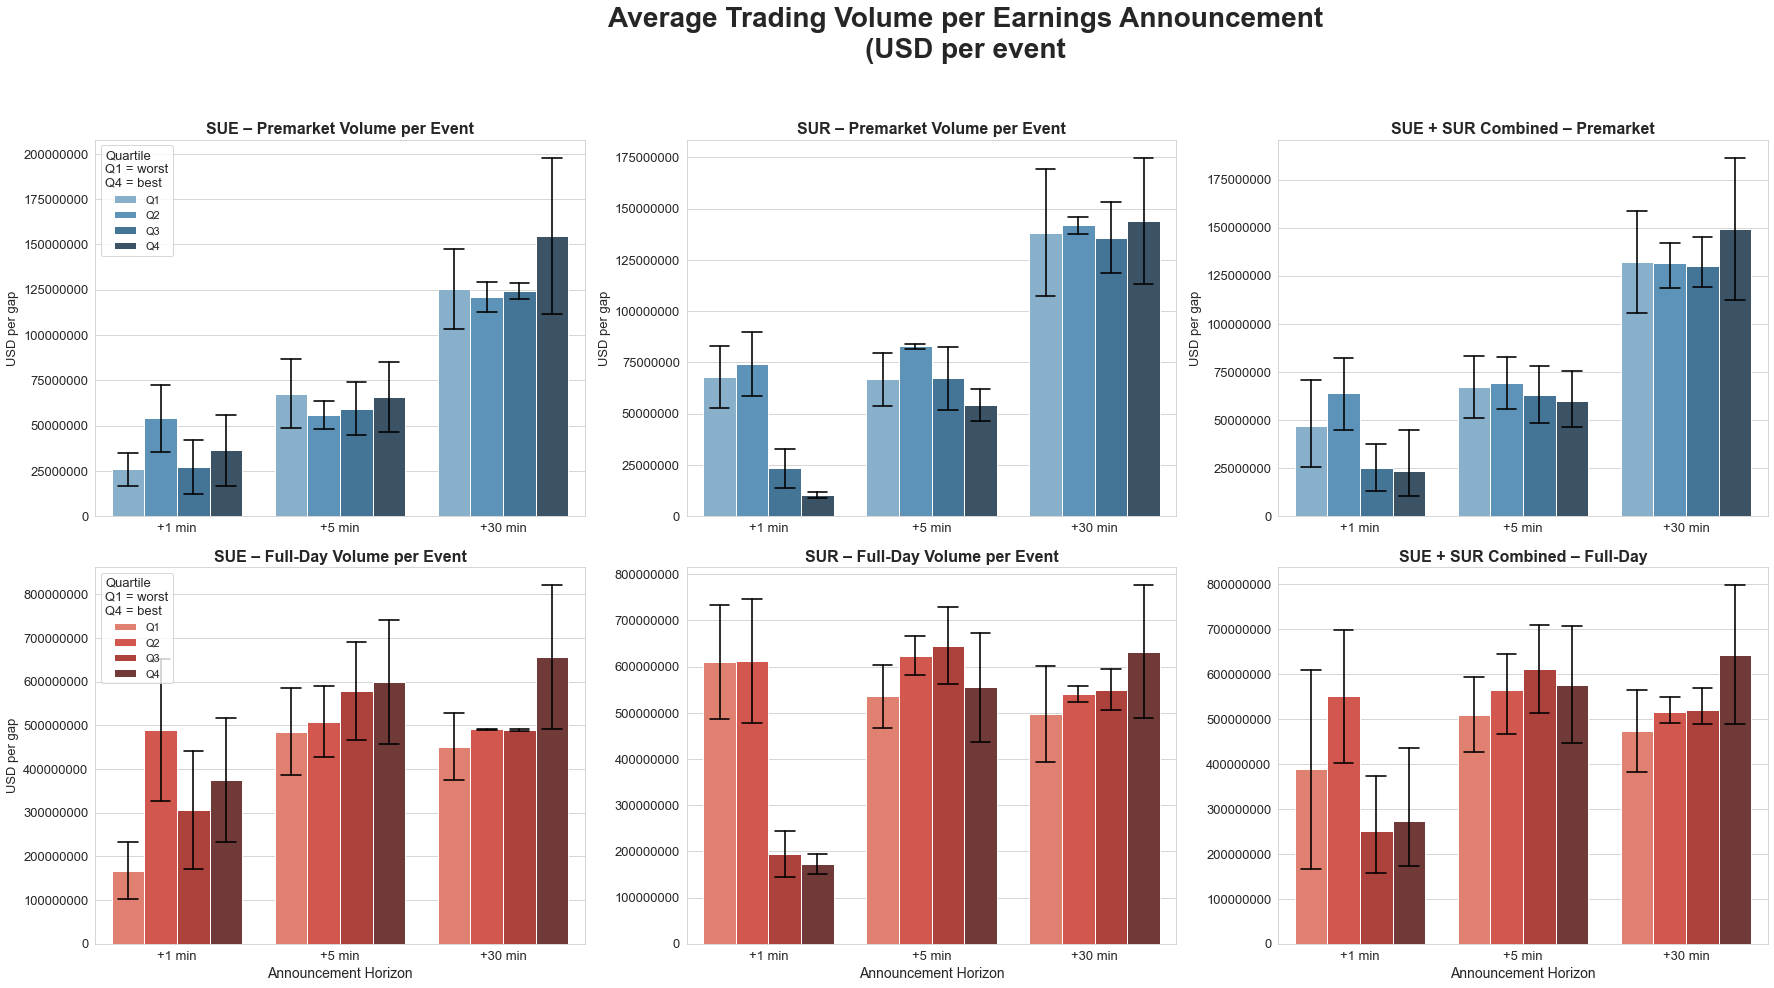

HOTOVO! Jedna čistá legenda na pravé straně pro všechny grafy (modré + červené)


In [3]:
# FINAL_VOLUME_PLOTS_PER_EVENT_CLEAN_LEGENDS_RIGHT.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# === NAČTI DATA ===
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\volume_analysis_quartiles_strict")
df = pd.read_csv(BASE / "volume_analysis_PER_EVENT.csv")

# === PŘEJMENUJ METRIKY ===
metric_map = {
    "EPS_Surprise": "SUE",
    "Revenue_Surprise": "SUR",
    "SUE_EPS": "SUE",
    "SUE_SUR": "SUE + SUR",
    "SUR_Rev": "SUR"
}
df["Metric"] = df["Metric"].map(metric_map)

df_sue      = df[df["Metric"] == "SUE"]
df_sur      = df[df["Metric"] == "SUR"]
df_combined = df[df["Metric"].isin(["SUE", "SUR"])]

# === NASTAVENÍ ===
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 13})
horizons_order = ["+1 min", "+5 min", "+30 min"]
quartiles_order = ["Q1", "Q2", "Q3", "Q4"]

# === 6 GRAFŮ – JEDNA SPOLEČNÁ LEGENDA NA PRAVÉ STRANĚ ===
fig, axes = plt.subplots(2, 3, figsize=(27, 14))
fig.suptitle("Average Trading Volume per Earnings Announcement\n(USD per event",
             fontsize=28, fontweight='bold', y=0.98)

def plot_volume(ax, data, y_col, title, legend=False):
    sns.barplot(data=data, x="Horizon", y=y_col, hue="Quartile",
                order=horizons_order, hue_order=quartiles_order,
                palette="Blues_d" if "Premarket" in title else "Reds_d",
                ax=ax, ci=95, capsize=0.12, errwidth=1.6, errcolor="black")

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_ylabel("USD per gap" if "Premarket" in title or ax in [axes[0,0], axes[1,0]] else "", fontsize=13)
    ax.set_xlabel("Announcement Horizon" if ax in axes[1,:] else "", fontsize=14)
    ax.ticklabel_format(style='plain', axis='y')
    
    # Pouze první graf (SUE premarket) má legendu – ta se pak přesune doprava
    if legend:
        ax.legend(title="Quartile\nQ1 = worst\nQ4 = best", loc="upper left", fontsize=11)
    else:
        ax.legend_.remove()

# 1. SUE
plot_volume(axes[0,0], df_sue, "Premarket_USD_per_event", "SUE – Premarket Volume per Event", legend=True)
plot_volume(axes[1,0], df_sue, "Full_Day_USD_per_event",   "SUE – Full-Day Volume per Event",   legend=True)

# 2. SUR → bez legendy uvnitř grafu
plot_volume(axes[0,1], df_sur, "Premarket_USD_per_event", "SUR – Premarket Volume per Event")
plot_volume(axes[1,1], df_sur, "Full_Day_USD_per_event",   "SUR – Full-Day Volume per Event")

# 3. SUE + SUR Combined → bez legendy uvnitř grafu
plot_volume(axes[0,2], df_combined, "Premarket_USD_per_event", "SUE + SUR Combined – Premarket")
plot_volume(axes[1,2], df_combined, "Full_Day_USD_per_event",   "SUE + SUR Combined – Full-Day")

# === JEDNA SPOLEČNÁ LEGENDA NA PRAVO (modrá + červená) ===
handles, labels = axes[0,0].get_legend_handles_labels()   # modrá (premarket)
handles2, labels2 = axes[1,0].get_legend_handles_labels() # červená (full-day)
handles += handles2
labels += labels2



plt.tight_layout(rect=[0, 0, 0.92, 0.95])  # udělá místo pro legendu
plt.savefig(BASE / "VOLUME_PER_EVENT_FINAL_RIGHT_LEGEND.png", dpi=300, bbox_inches='tight')
plt.savefig(BASE / "VOLUME_PER_EVENT_FINAL_RIGHT_LEGEND.pdf", bbox_inches='tight')
plt.show()

print("HOTOVO! Jedna čistá legenda na pravé straně pro všechny grafy (modré + červené)")

C:\Users\j-vas\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


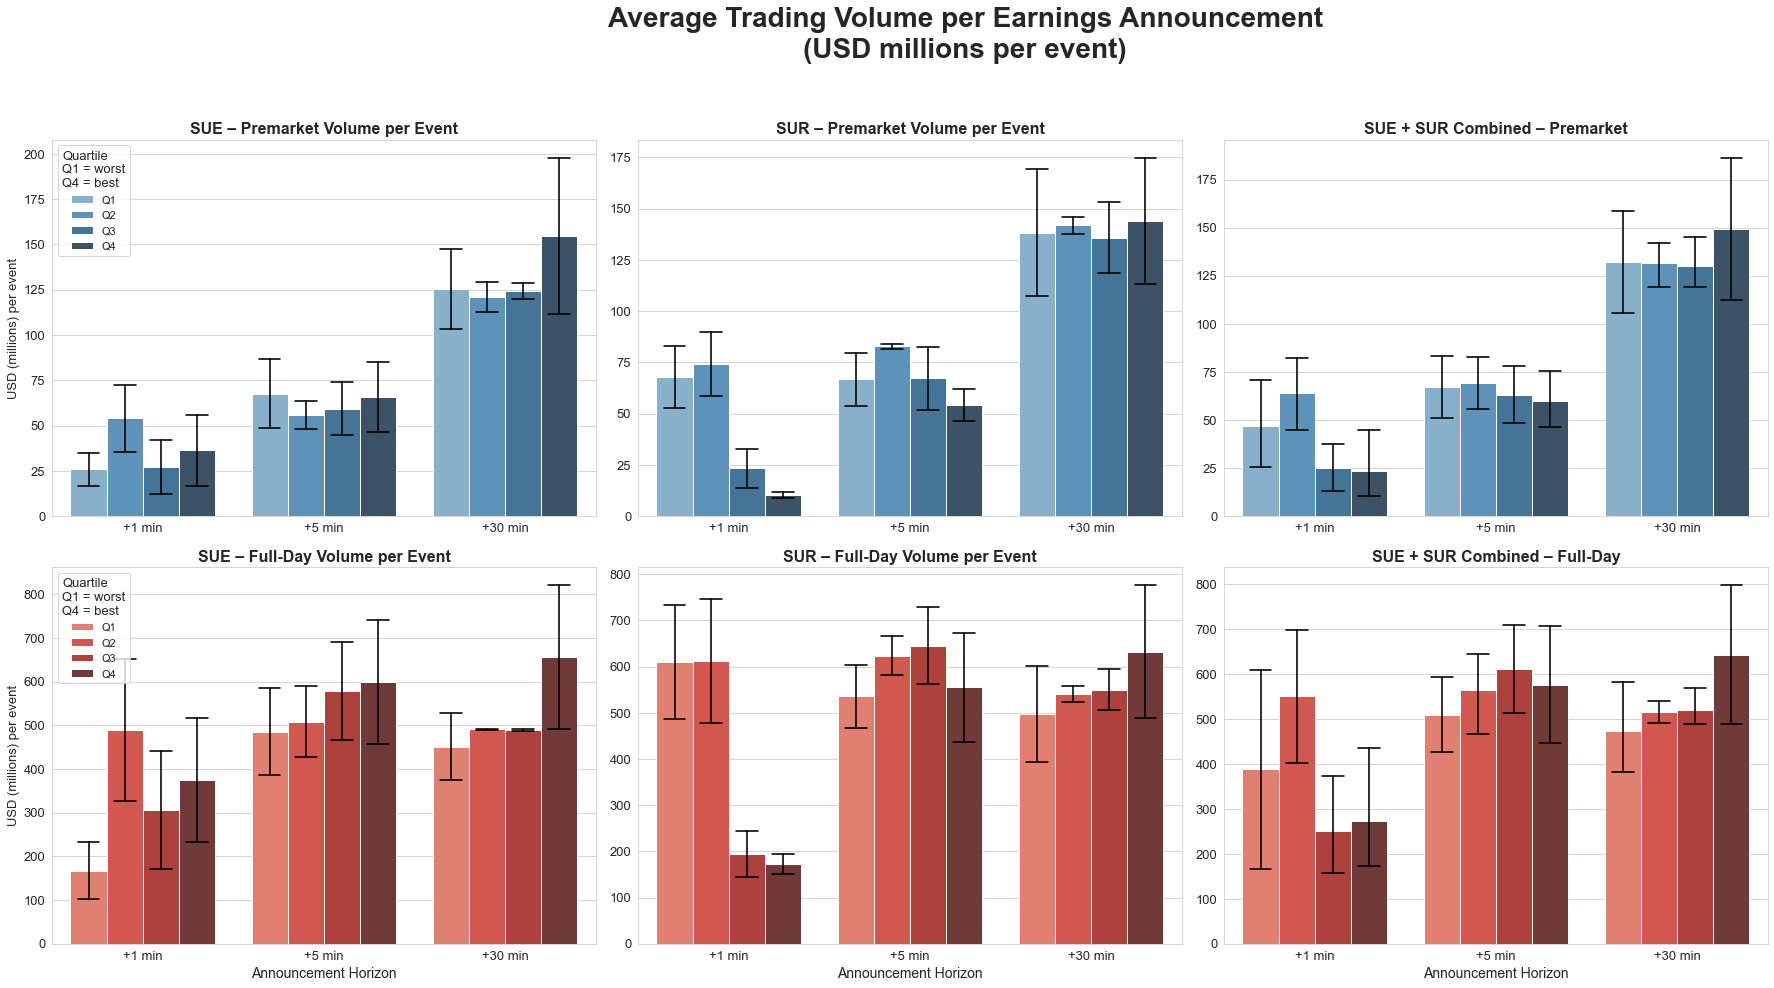

HOTOVO — volumes converted to USD millions, layout unchanged.


In [1]:
# =============================================================================
# FINAL_VOLUME_PLOTS_PER_EVENT_CLEAN_LEGENDS_RIGHT_MILLIONS.py
# → Identické grafy jako původně
# → Pouze změna jednotek: USD → USD millions
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# === LOAD DATA ===
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\volume_analysis_quartiles_strict")
df = pd.read_csv(BASE / "volume_analysis_PER_EVENT.csv")

# === SCALE TO MILLIONS ===
SCALE = 1_000_000
for col in [
    "Premarket_USD_per_event",
    "Full_Day_USD_per_event"
]:
    df[col] = df[col] / SCALE

# === RENAME METRICS ===
metric_map = {
    "EPS_Surprise": "SUE",
    "Revenue_Surprise": "SUR",
    "SUE_EPS": "SUE",
    "SUE_SUR": "SUE + SUR",
    "SUR_Rev": "SUR"
}
df["Metric"] = df["Metric"].map(metric_map)

df_sue      = df[df["Metric"] == "SUE"]
df_sur      = df[df["Metric"] == "SUR"]
df_combined = df[df["Metric"].isin(["SUE", "SUR"])]

# === SETTINGS ===
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 13})

horizons_order = ["+1 min", "+5 min", "+30 min"]
quartiles_order = ["Q1", "Q2", "Q3", "Q4"]

# === FIGURE ===
fig, axes = plt.subplots(2, 3, figsize=(27, 14))
fig.suptitle(
    "Average Trading Volume per Earnings Announcement\n(USD millions per event)",
    fontsize=28,
    fontweight='bold',
    y=0.98
)

def plot_volume(ax, data, y_col, title, legend=False):
    sns.barplot(
        data=data,
        x="Horizon",
        y=y_col,
        hue="Quartile",
        order=horizons_order,
        hue_order=quartiles_order,
        palette="Blues_d" if "Premarket" in title else "Reds_d",
        ax=ax,
        ci=95,
        capsize=0.12,
        errwidth=1.6,
        errcolor="black"
    )

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_ylabel(
        "USD (millions) per event" if ax in [axes[0,0], axes[1,0]] else "",
        fontsize=13
    )
    ax.set_xlabel(
        "Announcement Horizon" if ax in axes[1, :] else "",
        fontsize=14
    )

    if legend:
        ax.legend(
            title="Quartile\nQ1 = worst\nQ4 = best",
            loc="upper left",
            fontsize=11
        )
    else:
        ax.legend_.remove()

# === SUE ===
plot_volume(
    axes[0,0],
    df_sue,
    "Premarket_USD_per_event",
    "SUE – Premarket Volume per Event",
    legend=True
)
plot_volume(
    axes[1,0],
    df_sue,
    "Full_Day_USD_per_event",
    "SUE – Full-Day Volume per Event",
    legend=True
)

# === SUR ===
plot_volume(
    axes[0,1],
    df_sur,
    "Premarket_USD_per_event",
    "SUR – Premarket Volume per Event"
)
plot_volume(
    axes[1,1],
    df_sur,
    "Full_Day_USD_per_event",
    "SUR – Full-Day Volume per Event"
)

# === SUE + SUR COMBINED ===
plot_volume(
    axes[0,2],
    df_combined,
    "Premarket_USD_per_event",
    "SUE + SUR Combined – Premarket"
)
plot_volume(
    axes[1,2],
    df_combined,
    "Full_Day_USD_per_event",
    "SUE + SUR Combined – Full-Day"
)

# === LAYOUT & SAVE ===
plt.tight_layout(rect=[0, 0, 0.92, 0.95])

plt.savefig(
    BASE / "VOLUME_PER_EVENT_FINAL_RIGHT_LEGEND_MILLIONS.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    BASE / "VOLUME_PER_EVENT_FINAL_RIGHT_LEGEND_MILLIONS.pdf",
    bbox_inches="tight"
)

plt.show()

print("HOTOVO — volumes converted to USD millions, layout unchanged.")


In [10]:
df

,Horizon,Metric,Quartile,N,Gap_pct_mean,Gap_pct_median,Gap_pct_std
0,+1 min,SUE,Q1,37,25.999185,18.863049,21.298705
1,+1 min,SUE,Q2,36,22.108727,17.792865,13.577801
2,+1 min,SUE,Q3,36,21.519004,19.570685,14.157712
3,+1 min,SUE,Q4,36,23.605688,22.617253,10.814715
4,+1 min,SUR,Q1,30,26.099131,22.010017,15.759393
5,+1 min,SUR,Q2,30,20.883030,15.918553,15.073890
6,+1 min,SUR,Q3,29,22.295202,21.846154,8.337540
7,+1 min,SUR,Q4,30,23.300508,20.114359,13.804770
8,+1 min,SUE,Q1,29,25.500507,23.214286,18.431473
9,+1 min,SUE,Q2,29,19.766560,15.031847,12.306224


In [6]:
# =============================================================================
# 1_GAP_PERCENT_ANALYSIS_FROM_OHLC_ROBUST_FINAL.py
# → Computes gap % from previous close to today's open per earnings event
# → Uses OHLC only, calculates mean, median, std per metric/quartile/horizon
# =============================================================================

import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME")
QUARTILES_DIR = BASE / "news_final" / "quartiles"
OHLC_FILE = BASE / "daily_ohlc_unfiltered.csv"  # single CSV with all OHLC data
OUT_DIR = BASE / "gap_percent_analysis_quartiles_from_ohlc"
OUT_DIR.mkdir(exist_ok=True)

# --- Load OHLC data ---
ohlc = pd.read_csv(OHLC_FILE, parse_dates=["Date"], low_memory=False)
ohlc["symbol"] = ohlc["Ticker"].str.upper()
ohlc = ohlc.sort_values(["symbol", "Date"])

# Compute previous day's close
ohlc["prev_close"] = ohlc.groupby("symbol")["Close"].shift(1)
ohlc["gap_pct"] = (ohlc["Open"] - ohlc["prev_close"]) / ohlc["prev_close"] * 100
ohlc = ohlc[["symbol", "Date", "gap_pct"]]

results = []

# --- Process each horizon and quartile ---
HORIZONS = ["plus1", "plus5", "plus30"]

for horizon_key in HORIZONS:
    folder = QUARTILES_DIR / horizon_key
    if not folder.exists():
        print(f"Folder does not exist: {folder}")
        continue

    print(f"\nProcessing horizon: {horizon_key}")

    for csv_file in folder.glob("*_Q?.csv"):
        df = pd.read_csv(csv_file)
        if df.empty or "symbol" not in df.columns or "Date" not in df.columns:
            continue
        
        df["Date"] = pd.to_datetime(df["Date"])
        df["symbol"] = df["symbol"].str.upper()
        
        # Metric and quartile from filename
        parts = csv_file.stem.split("_")
        metric = "_".join(parts[1:-1])
        quartile = parts[-1]
        
        # Merge with OHLC to get gap %
        df = df.merge(ohlc, on=["symbol", "Date"], how="left")
        df["gap_pct"] = df["gap_pct"].fillna(0)
        
        n = len(df)
        if n == 0:
            continue
        
        results.append({
            "Horizon": horizon_key.replace("plus", "+").replace("1", "1 min")
                                .replace("5", "5 min").replace("30", "30 min"),
            "Metric": metric,
            "Quartile": quartile,
            "N": n,
            "Gap_pct_mean": df["gap_pct"].mean(),
            "Gap_pct_median": df["gap_pct"].median(),
            "Gap_pct_std": df["gap_pct"].std(),
        })

# --- Final table ---
if results:
    final = pd.DataFrame(results)
    final = final.sort_values(["Horizon", "Metric", "Quartile"]).reset_index(drop=True)
    
    out_file = OUT_DIR / "gap_percent_analysis_by_quartile_from_ohlc.csv"
    final.to_csv(out_file, index=False, encoding="utf-8-sig")
    print(f"\nDONE! Table saved: {out_file}")
    print(f"Total rows: {len(final)}")
else:
    print("No results to save – no valid quartiles found.")



Processing horizon: plus1

Processing horizon: plus5

Processing horizon: plus30

DONE! Table saved: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\gap_percent_analysis_quartiles_from_ohlc\gap_percent_analysis_by_quartile_from_ohlc.csv
Total rows: 60


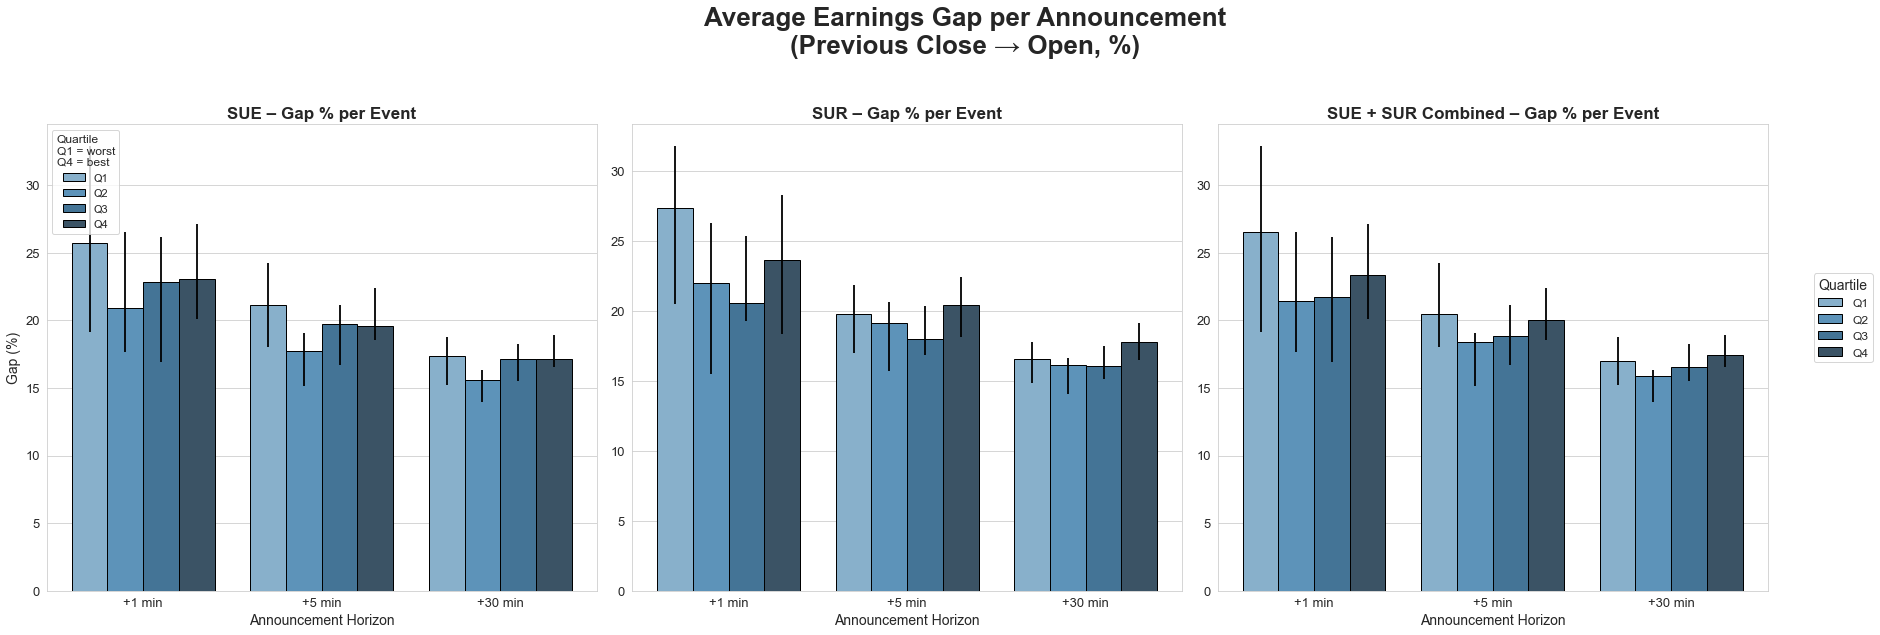

HOTOVO! 3 clean gap % charts, no warnings, one legend on the right.


In [8]:
# =============================================================================
# FINAL_GAP_PERCENT_PLOTS_PER_EVENT_3CHARTS_RIGHT_LEGEND.py
# → 3 charts: SUE / SUR / SUE+SUR
# → Gap % from previous close → open
# → Mean with 95% CI lines
# → One clean legend on the right
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# === LOAD DATA ===
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\gap_percent_analysis_quartiles_from_ohlc")
df = pd.read_csv(BASE / "gap_percent_analysis_by_quartile_from_ohlc.csv")

# === MAP METRICS ===
metric_map = {
    "EPS_Surprise": "SUE",
    "Revenue_Surprise": "SUR",
    "SUE_EPS": "SUE",
    "SUE_SUR": "SUE + SUR",
    "SUR_Rev": "SUR"
}
df["Metric"] = df["Metric"].map(metric_map)

# === SPLIT DATA (COPY → NO WARNINGS) ===
df_sue      = df[df["Metric"] == "SUE"].copy()
df_sur      = df[df["Metric"] == "SUR"].copy()
df_combined = df[df["Metric"].isin(["SUE", "SUR"])].copy()

# === SETTINGS ===
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 13})

horizons_order  = ["+1 min", "+5 min", "+30 min"]
quartiles_order = ["Q1", "Q2", "Q3", "Q4"]

# === FIGURE ===
fig, axes = plt.subplots(1, 3, figsize=(27, 9))
fig.suptitle(
    "Average Earnings Gap per Announcement\n(Previous Close → Open, %)",
    fontsize=26,
    fontweight="bold",
    y=0.98
)

def plot_gap(ax, data, title, show_legend=False):
    # --- Compute CI locally (NO dataframe mutation) ---
    ci_low  = data["Gap_pct_mean"] - 1.96 * data["Gap_pct_std"] / np.sqrt(data["N"])
    ci_high = data["Gap_pct_mean"] + 1.96 * data["Gap_pct_std"] / np.sqrt(data["N"])

    # --- Bars ---
    sns.barplot(
        data=data,
        x="Horizon",
        y="Gap_pct_mean",
        hue="Quartile",
        order=horizons_order,
        hue_order=quartiles_order,
        palette="Blues_d",
        ci=None,
        edgecolor="black",
        ax=ax
    )

    # --- CI lines ---
    n_quart = len(quartiles_order)
    total_width = 0.8
    bar_w = total_width / n_quart

    for i, h in enumerate(horizons_order):
        for j, q in enumerate(quartiles_order):
            mask = (data["Horizon"] == h) & (data["Quartile"] == q)
            if not mask.any():
                continue

            y_low  = ci_low[mask].values[0]
            y_high = ci_high[mask].values[0]

            x = i - total_width/2 + j*bar_w + bar_w/2
            ax.vlines(x, y_low, y_high, color="black", linewidth=1.8)

    ax.set_title(title, fontsize=17, fontweight="bold")
    ax.set_xlabel("Announcement Horizon", fontsize=14)
    ax.set_ylabel("Gap (%)" if ax == axes[0] else "", fontsize=14)

    if show_legend:
        ax.legend(
            title="Quartile\nQ1 = worst\nQ4 = best",
            fontsize=11,
            title_fontsize=12,
            loc="upper left"
        )
    else:
        ax.legend_.remove()

# === PLOTS ===
plot_gap(axes[0], df_sue,      "SUE – Gap % per Event", show_legend=True)
plot_gap(axes[1], df_sur,      "SUR – Gap % per Event")
plot_gap(axes[2], df_combined, "SUE + SUR Combined – Gap % per Event")

# === SINGLE LEGEND ON RIGHT ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center right",
    bbox_to_anchor=(0.97, 0.5),
    title="Quartile",
    fontsize=12,
    title_fontsize=14,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.92, 0.95])

# === SAVE ===
plt.savefig(BASE / "GAP_PERCENT_PER_EVENT_3CHARTS_FINAL.png", dpi=300, bbox_inches="tight")
plt.savefig(BASE / "GAP_PERCENT_PER_EVENT_3CHARTS_FINAL.pdf", bbox_inches="tight")
plt.show()

print("HOTOVO! 3 clean gap % charts, no warnings, one legend on the right.")


In [9]:
final

,Horizon,Metric,Quartile,N,Gap_pct_mean,Gap_pct_median,Gap_pct_std
0,+1 min,EPS_Surprise,Q1,37,25.999185,18.863049,21.298705
1,+1 min,EPS_Surprise,Q2,36,22.108727,17.792865,13.577801
2,+1 min,EPS_Surprise,Q3,36,21.519004,19.570685,14.157712
3,+1 min,EPS_Surprise,Q4,36,23.605688,22.617253,10.814715
4,+1 min,Revenue_Surprise,Q1,30,26.099131,22.010017,15.759393
5,+1 min,Revenue_Surprise,Q2,30,20.883030,15.918553,15.073890
6,+1 min,Revenue_Surprise,Q3,29,22.295202,21.846154,8.337540
7,+1 min,Revenue_Surprise,Q4,30,23.300508,20.114359,13.804770
8,+1 min,SUE_EPS,Q1,29,25.500507,23.214286,18.431473
9,+1 min,SUE_EPS,Q2,29,19.766560,15.031847,12.306224


In [7]:
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\news_final")

files = {
    "+1 min": BASE / "mega_final1.csv",
    "+5 min": BASE / "mega_final5.csv",
    "+30 min": BASE / "mega_final30.csv",
}

metric_cols = ["SUE_EPS", "SUR_Rev", "Revenue_Surprise", "EPS_Surprise", "SUE_SUR"]

START_YEAR = 2016
SPLIT_YEARS = 3   # první 3 roky = in-sample

for horizon, path in files.items():

    print("\n" + "="*80)
    print(f"HORIZON: {horizon}")
    print("="*80)

    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df[df["Date"].dt.year >= START_YEAR].copy()

    # --- dopočet SUE_SUR ---
    if "SUE_EPS" in df.columns and "SUR_Rev" in df.columns:
        df["SUE_SUR"] = (df["SUE_EPS"] + df["SUR_Rev"]) / 2

    # --- časové rozdělení ---
    first_year = df["Date"].dt.year.min()
    split_year = first_year + SPLIT_YEARS - 1

    df_in  = df[df["Date"].dt.year <= split_year].copy()
    df_out = df[df["Date"].dt.year >  split_year].copy()
    df_full = df.copy()  # full-sample (look-ahead)

    print(f"In-sample years : {first_year}–{split_year}")
    print(f"Out-of-sample   : {split_year+1}–{df['Date'].dt.year.max()}")
    print(f"Full-sample     : {first_year}–{df['Date'].dt.year.max()}")

    for col in metric_cols:
        if col not in df.columns:
            print(f"\n{col}: NOT FOUND")
            continue

        in_col   = df_in[col].dropna()
        out_col  = df_out[col].dropna()
        full_col = df_full[col].dropna()

        if len(in_col) < 20 or len(out_col) < 20 or len(full_col) < 20:
            print(f"\n{col}: TOO FEW OBSERVATIONS")
            continue

        # --- kvartilové hranice ---
        q_in   = in_col.quantile([0.25, 0.50, 0.75])
        q_out  = out_col.quantile([0.25, 0.50, 0.75])
        q_full = full_col.quantile([0.25, 0.50, 0.75])

        # --- print 3x3 tabulka ---
        print("\n" + "-"*60)
        print(f"Metric: {col}")
        print("-"*60)
        print(f"{'Quartile':<10} {'In-sample':>12} {'Out-of-sample':>15} {'Full-sample':>15}")
        print(f"{'Q1':<10} {q_in.iloc[0]:>12.4f} {q_out.iloc[0]:>15.4f} {q_full.iloc[0]:>15.4f}")
        print(f"{'Q2':<10} {q_in.iloc[1]:>12.4f} {q_out.iloc[1]:>15.4f} {q_full.iloc[1]:>15.4f}")
        print(f"{'Q3':<10} {q_in.iloc[2]:>12.4f} {q_out.iloc[2]:>15.4f} {q_full.iloc[2]:>15.4f}")



HORIZON: +1 min
In-sample years : 2016–2018
Out-of-sample   : 2019–2024
Full-sample     : 2016–2024

------------------------------------------------------------
Metric: SUE_EPS
------------------------------------------------------------
Quartile      In-sample   Out-of-sample     Full-sample
Q1               0.3229          0.0596          0.0606
Q2               1.4564          0.7895          0.8456
Q3               2.3952          1.7163          1.8479

SUR_Rev: TOO FEW OBSERVATIONS

------------------------------------------------------------
Metric: Revenue_Surprise
------------------------------------------------------------
Quartile      In-sample   Out-of-sample     Full-sample
Q1               0.0238          0.0174          0.0174
Q2               0.0412          0.0854          0.0807
Q3               0.1858          0.1951          0.1951

------------------------------------------------------------
Metric: EPS_Surprise
--------------------------------------------------

In [6]:
import pandas as pd
from pathlib import Path

# ------------------------------------------------
# CONFIG
# ------------------------------------------------
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\news_final")

FILES = {
    "+1 min": BASE / "mega_final1.csv",
    "+5 min": BASE / "mega_final5.csv",
    "+30 min": BASE / "mega_final30.csv",
}

METRIC_COLS = [
    "SUE_EPS",
    "SUR_Rev",
    "EPS_Surprise",
    "Revenue_Surprise",
    "SUE_SUR"
]

START_YEAR = 2016
SPLIT_YEAR = 2019   # první 3 roky: 2016–2018
END_YEAR = 2023

# ------------------------------------------------
# PROCESS
# ------------------------------------------------
print("\n================ QUARTILE BOUNDARIES: IN-SAMPLE vs OUT-OF-SAMPLE ================\n")

for horizon, path in FILES.items():
    print(f"\n================ {horizon} =================")
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])

    # Restrict full period
    df = df[df["Date"].dt.year.between(START_YEAR, END_YEAR)].copy()

    # Construct SUE_SUR if missing
    if "SUE_SUR" not in df.columns and {"SUE_EPS", "SUR_Rev"}.issubset(df.columns):
        df["SUE_SUR"] = (df["SUE_EPS"] + df["SUR_Rev"]) / 2

    # Split samples
    df_in = df[df["Date"].dt.year < SPLIT_YEAR]
    df_out = df[df["Date"].dt.year >= SPLIT_YEAR]

    print(f"In-sample period: {df_in['Date'].dt.year.min()}–{df_in['Date'].dt.year.max()} (N={len(df_in)})")
    print(f"Out-of-sample period: {df_out['Date'].dt.year.min()}–{df_out['Date'].dt.year.max()} (N={len(df_out)})\n")

    for col in METRIC_COLS:
        if col not in df.columns:
            print(f"{col}: NOT FOUND")
            continue

        in_vals = df_in[col].dropna()
        out_vals = df_out[col].dropna()

        if len(in_vals) < 10 or len(out_vals) < 10:
            print(f"{col}: insufficient data")
            continue

        q_in = in_vals.quantile([0.25, 0.50, 0.75])
        q_out = out_vals.quantile([0.25, 0.50, 0.75])

        print(f"--- {col} ---")
        print("In-sample quartile cutoffs:")
        print(f"  Q1 (25%): {q_in.loc[0.25]:.4f}")
        print(f"  Q2 (50%): {q_in.loc[0.50]:.4f}")
        print(f"  Q3 (75%): {q_in.loc[0.75]:.4f}")

        print("Out-of-sample quartile cutoffs:")
        print(f"  Q1 (25%): {q_out.loc[0.25]:.4f}")
        print(f"  Q2 (50%): {q_out.loc[0.50]:.4f}")
        print(f"  Q3 (75%): {q_out.loc[0.75]:.4f}")
        print()



================ QUARTILE BOUNDARIES: IN-SAMPLE vs OUT-OF-SAMPLE ================


================ +1 min =================
In-sample period: 2016–2018 (N=814)
Out-of-sample period: 2019–2023 (N=5988)

--- SUE_EPS ---
In-sample quartile cutoffs:
  Q1 (25%): 0.3229
  Q2 (50%): 1.4564
  Q3 (75%): 2.3952
Out-of-sample quartile cutoffs:
  Q1 (25%): 0.0831
  Q2 (50%): 0.7812
  Q3 (75%): 2.0698

--- SUR_Rev ---
In-sample quartile cutoffs:
  Q1 (25%): 0.4910
  Q2 (50%): 1.3215
  Q3 (75%): 3.0247
Out-of-sample quartile cutoffs:
  Q1 (25%): 0.4567
  Q2 (50%): 1.0923
  Q3 (75%): 2.6867

--- EPS_Surprise ---
In-sample quartile cutoffs:
  Q1 (25%): 0.0616
  Q2 (50%): 0.4760
  Q3 (75%): 0.7500
Out-of-sample quartile cutoffs:
  Q1 (25%): 0.1029
  Q2 (50%): 0.4706
  Q3 (75%): 1.5227

--- Revenue_Surprise ---
In-sample quartile cutoffs:
  Q1 (25%): 0.0238
  Q2 (50%): 0.0412
  Q3 (75%): 0.1858
Out-of-sample quartile cutoffs:
  Q1 (25%): 0.0148
  Q2 (50%): 0.0924
  Q3 (75%): 0.2013

--- SUE_SUR ---
I